In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Read the Data

In [2]:
dataframe_QB_Passing_yards = pd.read_excel("../Player_Stats.xltx", sheet_name="Career_passing_yards")
dataframe_QB_Passing_TDS = pd.read_excel("../Player_Stats.xltx", sheet_name="Career_TDs")
dataframe_RB_Rushing_Yards = pd.read_excel("../Player_Stats.xltx", sheet_name="Career_Rushing_yards")
dataframe_RB_Rushing_TDS = pd.read_excel("../Player_Stats.xltx", sheet_name="Career_Rushing_TDS")
dataframe_WR_Rushing_Yards = pd.read_excel("../Player_Stats.xltx", sheet_name="Career_Recieving_Yards")
dataframe_WR_Rushing_TDS = pd.read_excel("../Player_Stats.xltx", sheet_name="Career_Recieving_TDS")

## Adapt the Data 

## Add the amount of Seasons in the NFL

In [3]:
for player in dataframe_QB_Passing_yards['Player']:
    if player in df_draft['name']:
        dataframe_QB_Passing_yards[player]['Draft_Position'] = df_draft['Player'==player]['pick']
    

NameError: name 'df_draft' is not defined

In [3]:
dataframe_RB_Rushing_Yards['Seasons in the NFL'] = [int(dataframe_RB_Rushing_Yards['Years'][i].split('-')[1]) - int(dataframe_RB_Rushing_Yards['Years'][i].split('-')[0]) + 1 for i in range(len(dataframe_RB_Rushing_Yards['Years']))]
dataframe_WR_Rushing_Yards['Seasons in the NFL'] = [int(dataframe_WR_Rushing_Yards['Years'][i].split('-')[1]) - int(dataframe_WR_Rushing_Yards['Years'][i].split('-')[0]) + 1 for i in range(len(dataframe_WR_Rushing_Yards['Years']))]


In [4]:
dataframe_RB_Rushing_Yards.head()
dataframe_WR_Rushing_Yards.head()

,Player,Yds,Years,Seasons in the NFL
0,Jerry Rice+,22895,1985-2004,20
1,Larry Fitzgerald+,17492,2004-2020,17
2,Terrell Owens+,15934,1996-2010,15
3,Randy Moss+,15292,1998-2012,15
4,Isaac Bruce+,15208,1994-2009,16


In [5]:
dataframe_QB_Passing_yards['Seasons in the NFL'] = dataframe_QB_Passing_yards['Sessions in NFL']

In [6]:
dataframe_QB_Passing_yards

,Player,Yds,year of draft,Unnamed: 3,Sessions in NFL,Seasons in the NFL
0,Tom Brady,89214,2000,2022,23,23
1,Drew Brees+,80358,2001,2020,20,20
2,Peyton Manning+,71940,1998,2015,18,18
3,Brett Favre+,71838,1991,2010,20,20
4,Aaron Rodgers,66274,2005,2025,21,21
...,...,...,...,...,...,...
245,Al Dorow,7708,1954,1962,9,9
246,Bo Nix,7706,2024,2025,2,2
247,Craig Erickson,7625,1992,1997,6,6
248,Matt Moore,7597,2007,2019,13,13


In [7]:
dataframe_QB_Passing_yards = dataframe_QB_Passing_yards.drop("Sessions in NFL", axis=1)

## Join the data

In [8]:
joined_QB_data = dataframe_QB_Passing_yards.merge(dataframe_QB_Passing_TDS, on="Player")
joined_RB_data = dataframe_RB_Rushing_Yards.merge(dataframe_RB_Rushing_TDS, on="Player")
joined_WR_data = dataframe_WR_Rushing_Yards.merge(dataframe_WR_Rushing_TDS, on="Player")

In [9]:
joined_QB_data.head()

,Player,Yds,year of draft,Unnamed: 3,Seasons in the NFL,TDs,Years
0,Tom Brady,89214,2000,2022,23,649,2000-2022
1,Drew Brees+,80358,2001,2020,20,571,2001-2020
2,Peyton Manning+,71940,1998,2015,18,539,1998-2015
3,Brett Favre+,71838,1991,2010,20,508,1991-2010
4,Aaron Rodgers,66274,2005,2025,21,527,2005-2025


In [10]:
joined_RB_data.head()

,Player,Yds,Years_x,Seasons in the NFL,TD,Years_y
0,Emmitt Smith+,18355,1990-2004,15,164,1990-2004
1,Walter Payton+,16726,1975-1987,13,110,1975-1987
2,Frank Gore,16000,2005-2020,16,81,2005-2020
3,Barry Sanders+,15269,1989-1998,10,99,1989-1998
4,Adrian Peterson,14918,2007-2021,15,120,2007-2021


In [11]:
joined_WR_data.head()

,Player,Yds,Years_x,Seasons in the NFL,TD,Years_y
0,Jerry Rice+,22895,1985-2004,20,197,1985-2004
1,Larry Fitzgerald+,17492,2004-2020,17,121,2004-2020
2,Terrell Owens+,15934,1996-2010,15,153,1996-2010
3,Randy Moss+,15292,1998-2012,15,156,1998-2012
4,Isaac Bruce+,15208,1994-2009,16,91,1994-2009


In [12]:
joined_QB_data['Position'] = 'QB'
joined_RB_data['Position'] = 'RB'
joined_WR_data['Position'] = 'WR'

In [14]:
joined_RB_data['year of draft'] = [int(joined_RB_data['Years_x'][i].split('-')[0]) for i in range(len(joined_RB_data))] 

In [15]:
joined_RB_data.drop(['Years_x', 'Years_y'], axis=1)

,Player,Yds,Seasons in the NFL,TD,Position,year of draft
0,Emmitt Smith+,18355,15,164,RB,1990
1,Walter Payton+,16726,13,110,RB,1975
2,Frank Gore,16000,16,81,RB,2005
3,Barry Sanders+,15269,10,99,RB,1989
4,Adrian Peterson,14918,15,120,RB,2007
...,...,...,...,...,...,...
196,Kevan Barlow,3984,6,30,RB,2001
197,Leroy Hoard,3964,10,36,RB,1990
198,BenJarvus Green-Ellis,3914,6,42,RB,2008
199,Raheem Mostert,3895,11,34,RB,2015


In [16]:
joined_WR_data['year of draft'] = [int(joined_WR_data['Years_x'][i].split('-')[0]) for i in range(len(joined_WR_data))] 
joined_WR_data.drop(['Years_x', 'Years_y'], axis=1)

,Player,Yds,Seasons in the NFL,TD,Position,year of draft
0,Jerry Rice+,22895,20,197,WR,1985
1,Larry Fitzgerald+,17492,17,121,WR,2004
2,Terrell Owens+,15934,15,153,WR,1996
3,Randy Moss+,15292,15,156,WR,1998
4,Isaac Bruce+,15208,16,91,WR,1994
...,...,...,...,...,...,...
197,Eric Decker,5816,8,53,WR,2010
198,Mike Ditka+,5812,12,43,WR,1961
199,Riley Odoms,5755,12,41,WR,1972
200,Roy Williams,5715,8,44,WR,2004


In [17]:
## Drop every player which was drafted before 1978

In [18]:
joined_QB_data = joined_QB_data[joined_QB_data['year of draft'] >= 1978]
joined_RB_data = joined_RB_data[joined_RB_data['year of draft'] >= 1978]
joined_WR_data = joined_WR_data[joined_WR_data['year of draft'] >= 1978]

## Transfrom the Data

In [19]:
joined_QB_data['Performance-Index'] = (joined_QB_data['Yds'] /  joined_QB_data['Yds'].max()) * 50 + (joined_QB_data['TDs'] /  joined_QB_data['TDs'].max()) * 50
joined_RB_data['Performance-Index'] = (joined_RB_data['Yds'] /  joined_RB_data['Yds'].max()) * 50 + (joined_RB_data['TD'] /  joined_RB_data['TD'].max()) * 50
joined_WR_data['Performance-Index'] = (joined_WR_data['Yds'] /  joined_WR_data['Yds'].max()) * 50 + (joined_WR_data['TD'] /  joined_WR_data['TD'].max()) * 50

In [20]:
joined_QB_data.head()

,Player,Yds,year of draft,Unnamed: 3,Seasons in the NFL,TDs,Years,Position,Performance-Index
0,Tom Brady,89214,2000,2022,23,649,2000-2022,QB,100.0
1,Drew Brees+,80358,2001,2020,20,571,2001-2020,QB,89.027408
2,Peyton Manning+,71940,1998,2015,18,539,1998-2015,QB,81.844208
3,Brett Favre+,71838,1991,2010,20,508,1991-2010,QB,79.398752
4,Aaron Rodgers,66274,2005,2025,21,527,2005-2025,QB,77.744198


## Plot the data

In [21]:
pd.concat([joined_QB_data, joined_RB_data, joined_WR_data])

,Player,Yds,year of draft,Unnamed: 3,Seasons in the NFL,TDs,Years,Position,Performance-Index,Years_x,TD,Years_y
0,Tom Brady,89214,2000,2022.0,23,649,2000-2022,QB,100.0,NaN,NaN,NaN
1,Drew Brees+,80358,2001,2020.0,20,571,2001-2020,QB,89.027408,NaN,NaN,NaN
2,Peyton Manning+,71940,1998,2015.0,18,539,1998-2015,QB,81.844208,NaN,NaN,NaN
3,Brett Favre+,71838,1991,2010.0,20,508,1991-2010,QB,79.398752,NaN,NaN,NaN
4,Aaron Rodgers,66274,2005,2025.0,21,527,2005-2025,QB,77.744198,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
194,Todd Heap,5869,2001,NaN,12,NaN,NaN,WR,23.477107,2001-2012,42.0,2001-2012
195,James Jones,5861,2007,NaN,9,NaN,NaN,WR,25.7439,2007-2015,51.0,2007-2015
197,Eric Decker,5816,2010,NaN,8,NaN,NaN,WR,26.15324,2010-2017,53.0,2010-2017
200,Roy Williams,5715,2004,NaN,8,NaN,NaN,WR,23.648404,2004-2011,44.0,2004-2011


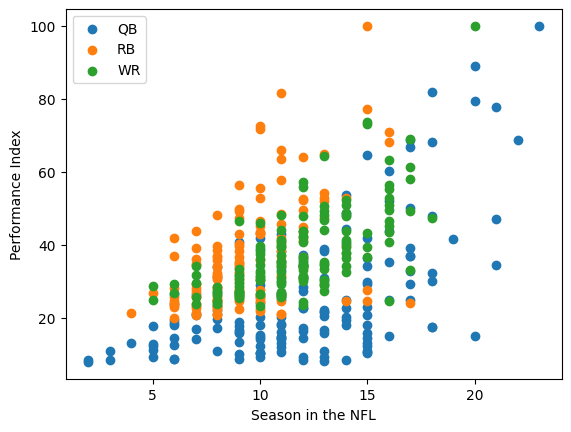

In [22]:
df = pd.concat([joined_QB_data, joined_RB_data, joined_WR_data])

for pos, group in df.groupby('Position'):
    plt.scatter(group['Seasons in the NFL'],
                group['Performance-Index'],
                label=pos)

plt.xlabel("Season in the NFL")
plt.ylabel("Performance Index")
plt.legend()
plt.show()